In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar os dados corrigidos do Iris do sklearn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# 2. Separar dados de treino e teste
# 'target' é a coluna que queremos prever, então a removemos de X para usarmos como y
X = df.drop('target', axis=1) # Características (medidas)
y = df['target']              # Alvo (espécie da flor)

# 3. Dividir os dados em 2/3 para treino e 1/3 para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

Melhor k encontrado: 3
Acurácia média (CV) nesse k: 93.00%


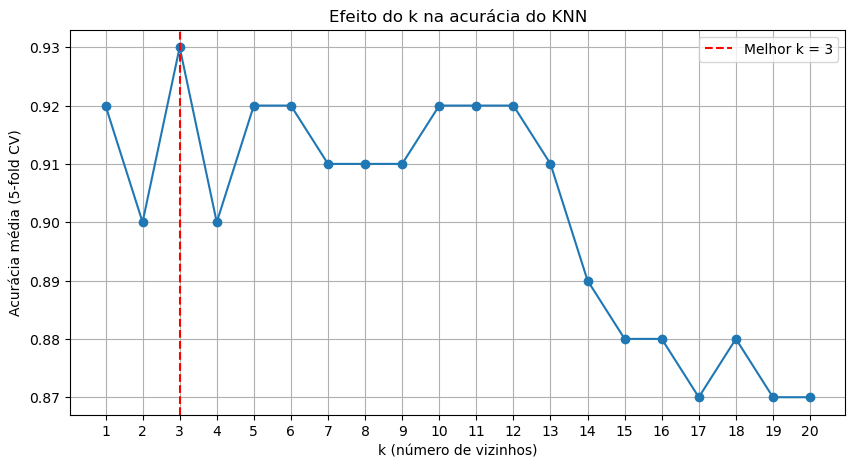


Acurácia do KNN no teste (k=3): 98.00%


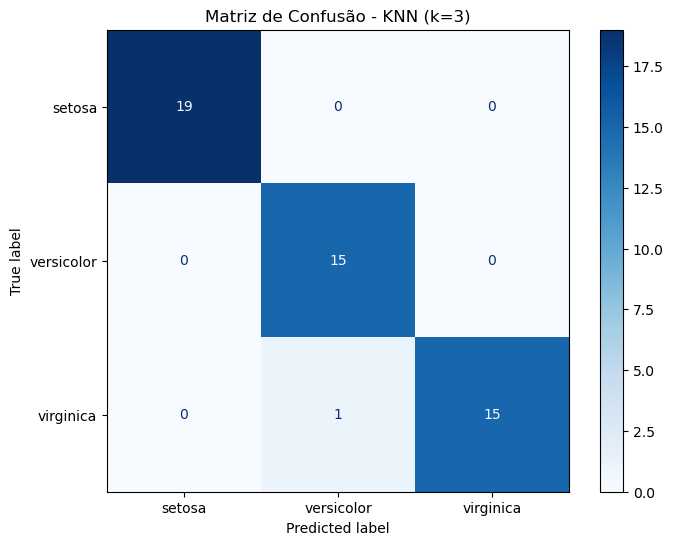

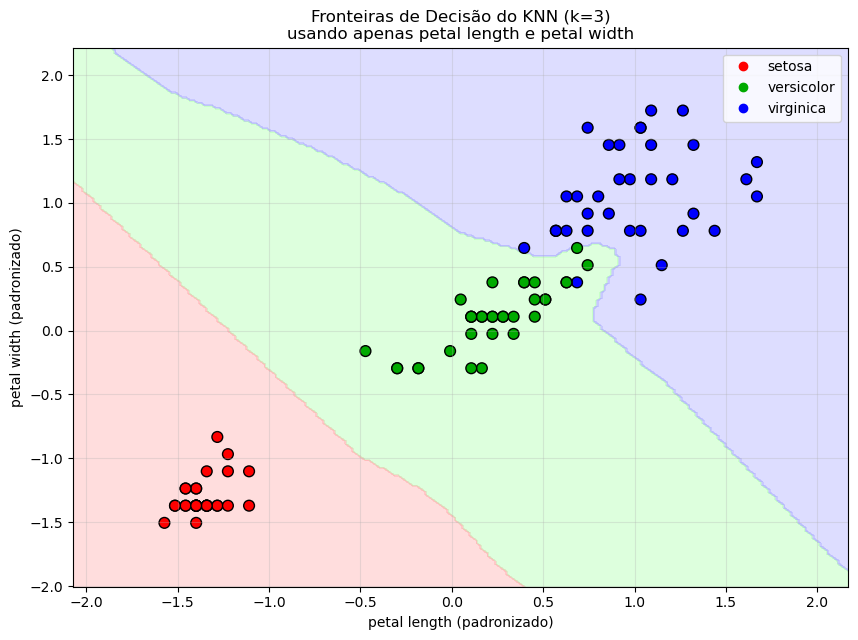

In [2]:
# ===== 1. PADRONIZAÇÃO =====
# KNN usa distância, então features em escalas diferentes prejudicam o modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== 2. ESCOLHA DO MELHOR K VIA VALIDAÇÃO CRUZADA =====
# Testar vários k's usando 5-fold CV no conjunto de TREINO
valores_k = range(1, 21)  # testar k de 1 a 20
scores_por_k = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5)
    scores_por_k.append(scores.mean())

melhor_k = valores_k[np.argmax(scores_por_k)]
print(f"Melhor k encontrado: {melhor_k}")
print(f"Acurácia média (CV) nesse k: {max(scores_por_k) * 100:.2f}%")

# Gráfico do efeito de k
plt.figure(figsize=(10, 5))
plt.plot(valores_k, scores_por_k, marker='o')
plt.axvline(melhor_k, color='red', linestyle='--', label=f'Melhor k = {melhor_k}')
plt.xlabel("k (número de vizinhos)")
plt.ylabel("Acurácia média (5-fold CV)")
plt.title("Efeito do k na acurácia do KNN")
plt.xticks(valores_k)
plt.legend()
plt.grid(True)
plt.show()

# ===== 3. TREINAR O MODELO FINAL COM O MELHOR K =====
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_train_scaled, y_train)

previsoes_knn = modelo_knn.predict(X_test_scaled)
precisao_knn = accuracy_score(y_test, previsoes_knn)
print(f"\nAcurácia do KNN no teste (k={melhor_k}): {precisao_knn * 100:.2f}%")

# ===== 4. MATRIZ DE CONFUSÃO =====
cm_knn = confusion_matrix(y_test, previsoes_knn)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=iris.target_names)
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Matriz de Confusão - KNN (k={melhor_k})")
plt.show()

# ===== 5. FRONTEIRAS DE DECISÃO (usando apenas petal length e petal width) =====
# Como temos 4 features, precisamos escolher 2 para visualizar em 2D.
# Escolhemos petal length (índice 2) e petal width (índice 3) por serem as mais discriminativas.
X_2d = X_train_scaled[:, [2, 3]]  # só petal length e petal width já padronizadas
modelo_2d = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_2d.fit(X_2d, y_train)

# Criar uma grade de pontos cobrindo todo o espaço 2D
h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Prever a classe de cada ponto da grade
Z = modelo_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotar fronteiras e pontos de treino
plt.figure(figsize=(10, 7))
cmap_fundo = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_pontos = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

plt.contourf(xx, yy, Z, cmap=cmap_fundo, alpha=0.4)
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap=cmap_pontos,
                      edgecolor='black', s=60)
plt.xlabel("petal length (padronizado)")
plt.ylabel("petal width (padronizado)")
plt.title(f"Fronteiras de Decisão do KNN (k={melhor_k})\nusando apenas petal length e petal width")
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.grid(True, alpha=0.3)
plt.show()